Shape: (256, 256, 26)
Dtype: float64


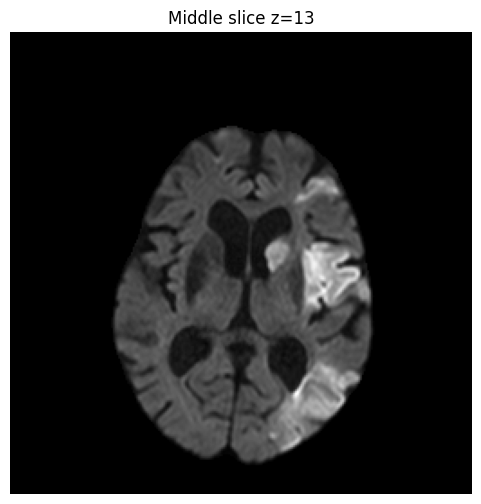

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Đường dẫn file .nii.gz
nii_path = "/mnt/disk1/SOOP_TRACE_STRIPPED/sub-638_rec-TRACE_dwi.nii.gz"
# nii_path = "/mnt/disk1/SOOP_raw/derivatives/lesion_masks/sub-6663888/dwi/sub-66388_space-TRACE_desc-lesion_mask.nii.gz"
# nii_path = "/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/data/nnUNet_raw_data_base/nnUNet_raw_data/Task500_Ischemic_Stroke_Test/imagesTs/ISLES22_0001_0000.nii.gz"
# Load ảnh
img = nib.load(nii_path)
data = img.get_fdata()

print("Shape:", data.shape)
print("Dtype:", data.dtype)

# Lấy slice giữa theo trục z
z = data.shape[2] // 2
slice_img = data[:, :, z]

# Hiển thị
plt.figure(figsize=(6, 6))
plt.imshow(np.rot90(slice_img), cmap="gray")
plt.title(f"Middle slice z={z}")
plt.axis("off")
plt.show()

In [ ]:
import SimpleITK as sitk


input_dwi = "/mnt/disk1/SOOP_TRACE_STRIPPED/sub-638_rec-TRACE_dwi.nii.gz"
input_adc = "/mnt/disk1/SOOP_ADC_STRIPPED/sub-638_rec-ADC_dwi.nii.gz"

output_adc = "/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/input/images/adc-brain-mri/adc.mha"
output_dwi = "/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/input/images/dwi-brain-mri/dwi.mha"
def nii_to_mha(input_path, output_path):
    img = sitk.ReadImage(input_path)   # đọc ảnh kèm metadata
    sitk.WriteImage(img, output_path)  # ghi ra .mha, metadata được giữ lại

nii_to_mha(input_dwi , output_dwi)
nii_to_mha(input_adc , output_adc) 

MetaImageIO (0x55a8b37cbf50): Unsupported or empty metaData item ITK_FileNotes of type Ssfound, won't be written to image file

MetaImageIO (0x55a8b37cbf50): Unsupported or empty metaData item aux_file of type Ssfound, won't be written to image file

MetaImageIO (0x55a8b37cbf50): Unsupported or empty metaData item descrip of type Ssfound, won't be written to image file

MetaImageIO (0x55a8b37cbf50): Unsupported or empty metaData item intent_name of type Ssfound, won't be written to image file

MetaImageIO (0x55a8b37cbf50): Unsupported or empty metaData item qto_xyz of type N3itk6MatrixIfLj4ELj4EEEfound, won't be written to image file

MetaImageIO (0x55a8b3813e30): Unsupported or empty metaData item ITK_FileNotes of type Ssfound, won't be written to image file

MetaImageIO (0x55a8b3813e30): Unsupported or empty metaData item aux_file of type Ssfound, won't be written to image file

MetaImageIO (0x55a8b3813e30): Unsupported or empty metaData item descrip of type Ssfound, won't be written

: 

# Converting the whole results .mha into .nii.gz for experiment

In [ ]:
import os
from pathlib import Path

import SimpleITK as sitk
import pandas as pd

input_root = Path("/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/batch/images/stroke-lesion-segmentation")
output_root = Path("/mnt/disk1/SEGMENTED_MASK")
csv_path = Path("/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/datasets/fold_raw_trace_fullmodal_mask/MRS/all_subject.csv")

all_subject_df = pd.read_csv(csv_path)
list_subjects = all_subject_df["subject_id"].astype(str).tolist()

for sub in list_subjects:
    input_mask = input_root / f"{sub}.mha"
    output_dir = output_root / sub / "dwi"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_mask = output_dir / f"{sub}_space-TRACE_desc-lesion_mask.nii.gz"

    if not input_mask.exists():
        print(f"[SKIP] Missing input: {input_mask}")
        continue

    try:
        img = sitk.ReadImage(str(input_mask))
        sitk.WriteImage(img, str(output_mask))
        print(f"[OK] Converted {sub}: {input_mask} -> {output_mask}")
    except Exception as e:
        print(f"[ERROR] Failed for {sub}: {e}")



[OK] Converted sub-1001: /mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/batch/images/stroke-lesion-segmentation/sub-1001.mha -> /mnt/disk1/SEGMENTED_MASK/sub-1001/dwi/sub-1001_space-TRACE_desc-lesion_mask.nii.gz
[OK] Converted sub-1003: /mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/batch/images/stroke-lesion-segmentation/sub-1003.mha -> /mnt/disk1/SEGMENTED_MASK/sub-1003/dwi/sub-1003_space-TRACE_desc-lesion_mask.nii.gz
[OK] Converted sub-1005: /mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/batch/images/stroke-lesion-segmentation/sub-1005.mha -> /mnt/disk1/SEGMENTED_MASK/sub-1005/dwi/sub-1005_space-TRACE_desc-lesion_mask.nii.gz
[OK] Converted sub-1010: /mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/batch/images/stroke-lesion-segmentation/sub-1010.mha -> /mnt/disk1/SEGMENTED_MASK/sub-1010/dwi/sub-1010_space-TRACE_

(26, 224, 224)


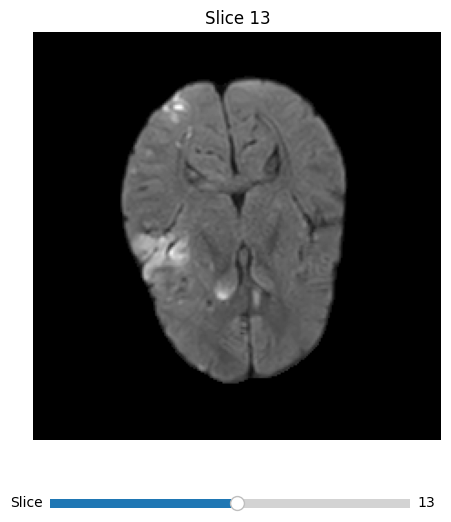

: 

In [ ]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# path = "/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/images/stroke-lesion-segmentation/dwi.mha"
path = "/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/input/images/dwi-brain-mri/dwi.mha"
img = sitk.ReadImage(path)
arr = sitk.GetArrayFromImage(img)   # (z, y, x)
print(arr.shape)

init_idx = arr.shape[0] // 2

fig, ax = plt.subplots(figsize=(6, 6))
plt.subplots_adjust(bottom=0.2)

im = ax.imshow(arr[init_idx], cmap="gray")
ax.set_title(f"Slice {init_idx}")
ax.axis("off")

slider_ax = plt.axes([0.2, 0.08, 0.6, 0.03])
slider = Slider(slider_ax, "Slice", 0, arr.shape[0] - 1, valinit=init_idx, valstep=1)

def update(val):
    idx = int(slider.val)
    im.set_data(arr[idx])
    ax.set_title(f"Slice {idx}")
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()